In [17]:
import matplotlib.pyplot as plt
from importlib import reload

import value_navigation.line as vnl

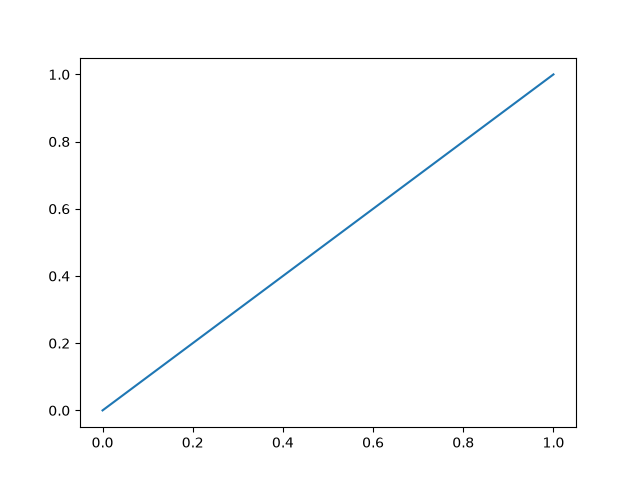

In [18]:
%matplotlib ipympl

f, ax = plt.subplots(1, 1)
ax.plot([0, 1], [0, 1])

In [29]:
line.bias

array([2., 2.])

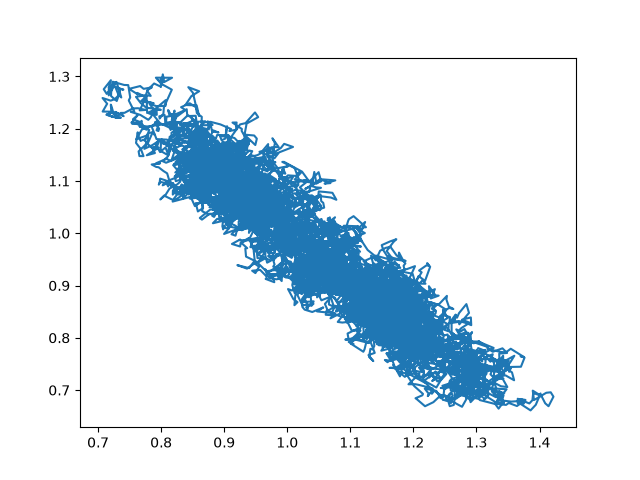

In [40]:
reload(vnl)

# Make and simulate a single line attractor with a noisy input
strength = 2
noise_std = .5 
n_neurs = 2
initial_condition = (1, 1)
integ_time = 10000 

line = vnl.SimpleLineAttractor(strength, n_neurs=n_neurs)
ni = vnl.make_noise_input(noise_std, n_neurs)
traj, ts = line.integrate(integ_time, init=initial_condition, input_func=ni)

f, ax = plt.subplots(1, 1)
ax.plot(*traj.T)
plt.show()

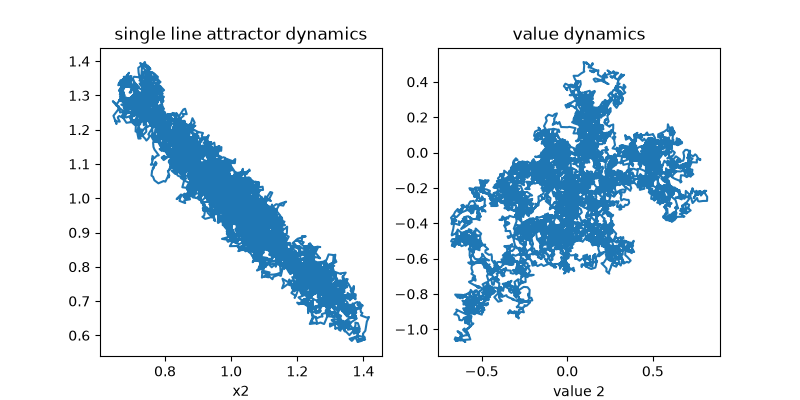

In [65]:
reload(vnl)

# Make and simulate a multi-line attractor with noise input

n_lines = 2
strength = 2
noise_std = .5 
n_neurs = 2 * n_lines
initial_condition = (1,) * n_neurs
integ_time = 10000 

mla = vnl.MultiLineAttractor(n_lines, strength)
ni = vnl.make_noise_input(noise_std, n_neurs)
traj, ts = mla.integrate(integ_time, init=initial_condition, input_func=ni)

fwid = 4
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(fwid * 2, fwid))
ax1.plot(*traj[:, :2].T)
ax1.set_xlabel("x1")
ax1.set_xlabel("x2")
ax1.set_title("single line attractor dynamics")

v1, v2 = vnl.value_readout(traj)
ax2.plot(v1, v2)
ax2.set_xlabel("value 1")
ax2.set_xlabel("value 2")
ax2.set_title("value dynamics")
plt.show()

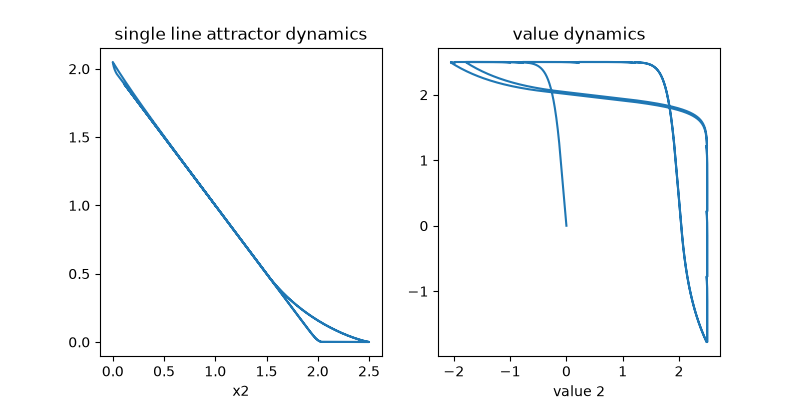

In [73]:
reload(vnl)

# Make and simulate a multi-line attractor with occupancy input

n_lines = 2
strength = 2
noise_std = .5 
n_neurs = 2 * n_lines
initial_condition = (1,) * n_neurs
integ_time = 10000 

depletion = .05
repletion = .5

mla = vnl.MultiLineAttractor(n_lines, strength)
occupancy = vnl.make_alternating_occupancy_func(n_lines)
dr_inp = vnl.make_depletion_repletion_input(occupancy, depletion, repletion)
traj, ts = mla.integrate(integ_time, init=initial_condition, input_func=dr_inp)

fwid = 4
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(fwid * 2, fwid))
ax1.plot(*traj[:, :2].T)
ax1.set_xlabel("x1")
ax1.set_xlabel("x2")
ax1.set_title("single line attractor dynamics")

v1, v2 = vnl.value_readout(traj)
ax2.plot(v1, v2)
ax2.set_xlabel("value 1")
ax2.set_xlabel("value 2")
ax2.set_title("value dynamics")
plt.show()

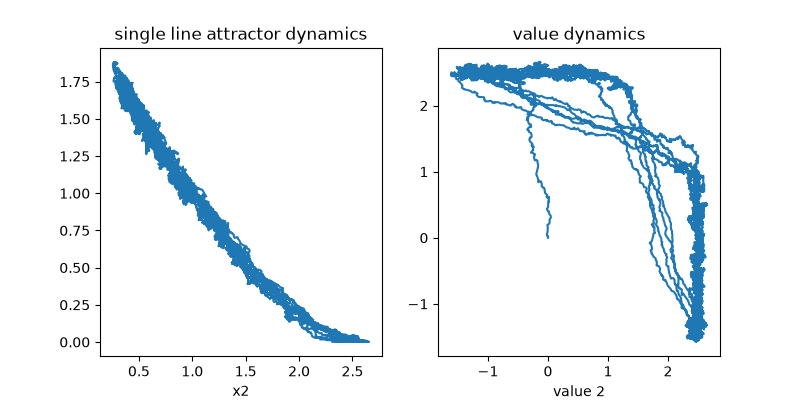

In [78]:
reload(vnl)

# Make and simulate a multi-line attractor with occupancy input

n_lines = 2
strength = 2
noise_std = .5 
n_neurs = 2 * n_lines
initial_condition = (1,) * n_neurs
integ_time = 20000 

depletion = .05
repletion = .5

mla = vnl.MultiLineAttractor(n_lines, strength)
occupancy = vnl.make_alternating_occupancy_func(n_lines)
dr_inp = vnl.make_depletion_repletion_input(occupancy, depletion, repletion)
noise_inp = vnl.make_noise_input(noise_std, n_neurs)
inp = vnl.make_composite_input(dr_inp, noise_inp)

traj, ts = mla.integrate(integ_time, init=initial_condition, input_func=inp)

fwid = 4
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(fwid * 2, fwid))
ax1.plot(*traj[:, :2].T)
ax1.set_xlabel("x1")
ax1.set_xlabel("x2")
ax1.set_title("single line attractor dynamics")

v1, v2 = vnl.value_readout(traj)
ax2.plot(v1, v2)
ax2.set_xlabel("value 1")
ax2.set_xlabel("value 2")
ax2.set_title("value dynamics")
plt.show()

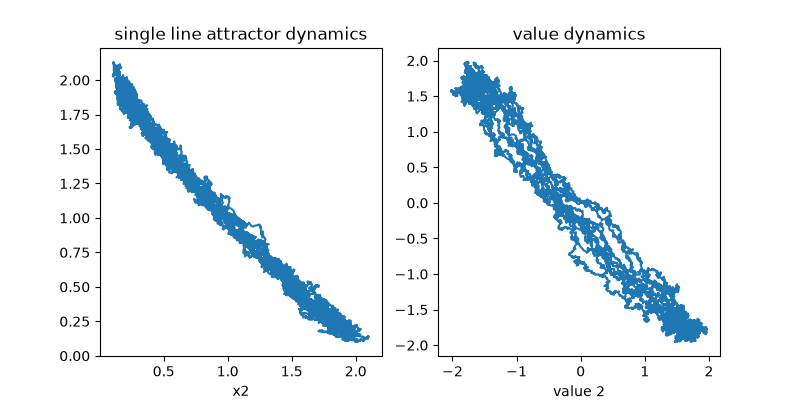

In [81]:
reload(vnl)

# Make some functions to help do this! 
depletion = .1
repletion = .1
traj, _ = vnl.simulate_multiline(depletion, repletion)
vnl.plot_multiline(traj)
plt.show()
                       

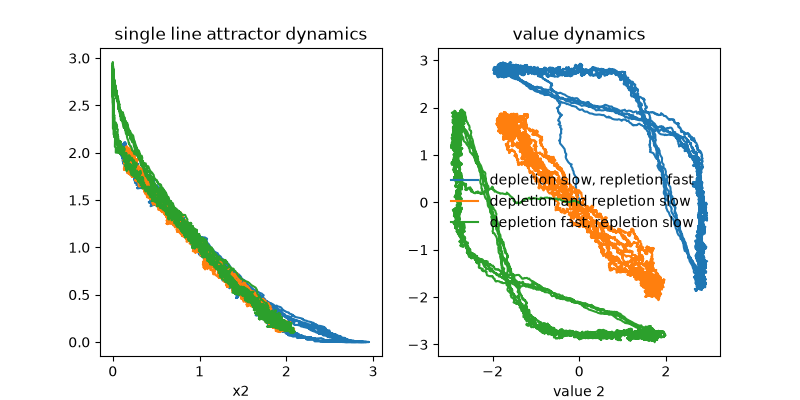

In [85]:
reload(vnl)

# Explore qualitatively before for different depletion-repletion choices
dr_pairs = (
    (.1, .8), # correct-ish params
    (.1, .1), # naive params?
    (.8, .1), # just wrong!
)
labels = ("depletion slow, repletion fast", "depletion and repletion slow", "depletion fast, repletion slow")
f, axs = plt.subplots(1, 2, figsize=(fwid * 2, fwid))
for i, (depletion, repletion) in enumerate(dr_pairs):
    traj, _ = vnl.simulate_multiline(depletion, repletion)
    vnl.plot_multiline(traj, axs=axs, label=labels[i])
plt.show()
                       